# Gamma Spec Calibration (Debug + Peak Fit Plots)

This notebook is a *drop-in* version of your current calibration workflow, with two critical upgrades:

1. **Robust dt parsing** for your CSV headers (including merged `...Elapsed Real Time:,<seconds>` lines).
2. **Debug plotting** for peak discovery and Gaussian fits so you can visually verify that:
   - peaks are being detected in the right places,
   - the fit window is sane,
   - the fitted Gaussian+linear background matches the data,
   - rejected peaks have an obvious reason.

Key fixes vs your last run:
- `baseline_cs` selection now **cannot accidentally pick Ba** (it matches isotope names in the filename, not substrings like `"cs"`).
- Peak fitting can be debug-plotted with `CFG["debug_peak_fits"]=True`.
- For **background-subtracted** spectra, the fitter allows negative baselines and doesn't over-reject peaks.

---


In [1]:
'''

We perform two calibration processes:
    
    One long calibration, where we calibrate with
        Co-60, Na (preamp 100)
        Ba, Cs, Co-57 (preamp 0; Co-57 done overnight)
    this long calibration is done only once (Feb 24; Co-57 run was done 5:45 PM Feb 24-3PM Feb 25).

    *Every* time we take data, we will do a single Cs (preamp level 0) and a Co-60 (preamp level 100) run to 
    see the variation in our ADC output compared to the previous baseline.

    In our final draft these calibrations have to be made to account for the background. The background analysis is also done here.
    
'''

'\n\nWe perform two calibration processes:\n\n    One long calibration, where we calibrate with\n        Co-60, Na (preamp 100)\n        Ba, Cs, Co-57 (preamp 0; Co-57 done overnight)\n    this long calibration is done only once (Feb 24; Co-57 run was done 5:45 PM Feb 24-3PM Feb 25).\n\n    *Every* time we take data, we will do a single Cs (preamp level 0) and a Co-60 (preamp level 100) run to \n    see the variation in our ADC output compared to the previous baseline.\n\n    In our final draft these calibrations have to be made to account for the background. The background analysis is also done here.\n\n'

### Why we **don’t enforce** reduced-χ² for peak acceptance (by default)

In NaI(Tl) spectra, photopeaks often have **non-Gaussian tails** and sit on **structured backgrounds** (Compton continuum, backscatter features).  
A strict Gaussian+linear model can still give an excellent **centroid** even when reduced-χ² looks “bad”.

So this notebook:
- **fits Gaussian + linear background** (as required),
- reports `χ²/ndf` for diagnostics,
- but does **not** reject peaks purely because `χ²/ndf` is large (unless you set `CFG["enforce_chi2"]=True`).

This fixes the exact failure mode you saw: visually good fits being thrown away with `FAILED: chi2/ndf too large`. 


In [2]:
'''

Naming schema: notation.

I denote file folders with [] and nuclear data files with {}

'''

'\n\nNaming schema: notation.\n\nI denote file folders with [] and nuclear data files with {}\n\n'

In [3]:
'''

ROUGH FILE STRUCTURE

[] calibration
    [] feb_24
        [] preamp_100
            {} Co60 _22.5C_preamp100_feb24
            {} Na_22.5C_preamp100_feb24
        [] preamp_0
            {} Ba_22.4C_preamp0_feb24
            {} Cs_22.1C_preamp0_feb24
    [] daily
        {} Cs_22.4C_preamp0_feb26
        {} Co60_22.4C_preamp100_feb26

'''

'\n\nROUGH FILE STRUCTURE\n\n[] calibration\n    [] feb_24\n        [] preamp_100\n            {} Co60 _22.5C_preamp100_feb24\n            {} Na_22.5C_preamp100_feb24\n        [] preamp_0\n            {} Ba_22.4C_preamp0_feb24\n            {} Cs_22.1C_preamp0_feb24\n    [] daily\n        {} Cs_22.4C_preamp0_feb26\n        {} Co60_22.4C_preamp100_feb26\n\n'

In [4]:
'''

Goal:
    Subtract background data from our data fit
    
    Generate a calibration curve from the big run (Feb 24)
        There should be two such curves, one for preamp level 0 and preamp level 100
    
    Generate a data algorithm which adjusts our day-by-day analysis for changes in ADC output
        There should be two such curves, one for preamp level 0 and preamp level 100
    Any change from the big run should be roughly on the order of 13 ADC channels (quite small, but worth accounting for anyways)
    We want to do this by forcefully changing the slope (?) or something from the original calibration curve

    This code should produce a calibration curve graph for our feb 24 run, as well as our night runs for co-57 
    (using whatever schema we choose to use to account for the calibration curve of these data points)

    Every trial we take, with the exception of the background run, is 15 minutes.
    
'''

'\n\nGoal:\n    Subtract background data from our data fit\n\n    Generate a calibration curve from the big run (Feb 24)\n        There should be two such curves, one for preamp level 0 and preamp level 100\n\n    Generate a data algorithm which adjusts our day-by-day analysis for changes in ADC output\n        There should be two such curves, one for preamp level 0 and preamp level 100\n    Any change from the big run should be roughly on the order of 13 ADC channels (quite small, but worth accounting for anyways)\n    We want to do this by forcefully changing the slope (?) or something from the original calibration curve\n\n    This code should produce a calibration curve graph for our feb 24 run, as well as our night runs for co-57 \n    (using whatever schema we choose to use to account for the calibration curve of these data points)\n\n    Every trial we take, with the exception of the background run, is 15 minutes.\n\n'

In [5]:
# -----------------------------
# IMPORT STATEMENTS
# -----------------------------
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit


In [6]:
# -----------------------------
# CONFIG: USER SETUP (EDIT ME)
# -----------------------------

ROOT_CAL = Path("processed_data/calibration")  # folder of converted calibration CSVs
BG_DEFAULT = Path("processed_data/calibration/background_550PM_feb26_213PM_mar3.csv")  # or None

CFG = {
    # Peak finding (global)
    "smooth_window": 21,
    "smooth_poly": 3,
    "min_distance": 20,
    "prominence_frac": 0.005,
    "max_peaks_global": 40,

    # Peak fitting windows
    "fit_half_window": 60,
    "fit_min_points": 25,
    "sigma_bounds": (1.0, 250.0),

    # Fit QA
"min_amp_snr": 2.0,
    "sys_frac": 0.02,          # fractional systematic added in quadrature to errors for peak fitting
    "enforce_chi2": False,     # if False, keep peaks even when chi2/ndf is large (still reported)
    "max_chi2_ndf": 200.0,     # only used if enforce_chi2=True
    "require_positive_amp": True,   # used for RAW spectra; for NET spectra we relax internally

    # Drift tracking windows
    "track_search_half_window": 100,
    "track_fit_half_window": 70,

    # Calibration model
    "cal_model": "linear",  # "linear" or "quadratic"

    # DEBUG
    "debug_peak_fits": True,       # turn on/off debug plots
    "debug_max_peak_plots": 12,    # cap plots per spectrum
    "debug_plot_failed_fits": True # also plot failed fits (useful early on)
}


In [7]:
# -----------------------------
# KNOWN GAMMA LINES (keV)
# -----------------------------
Cs_spectra     = np.array([31.8, 37.3, 661.657])
Cs_spectra_err = np.array([0,    0,    0.003])

Ba_spectra     = np.array([53.15, 79.60, 80.998, 160.605, 223.246, 276.397, 302.851, 356.005, 383.851])
Ba_spectra_err = np.array([0.05,  0.05,  0.008,  0.015,   0.030,   0.012,   0.015,   0.017,   0.020])

Co60_spectra     = np.array([1173.228, 1332.494])
Co60_spectra_err = np.array([0.003,    0.002])

Na_spectra     = np.array([511.006, 1274.537])
Na_spectra_err = np.array([0,       0.008])

Co57_spectra     = np.array([14.4136, 122.060, 136.471, 570.1, 692.4])
Co57_spectra_err = np.array([0.0003,  0.010,   0.010,   0.2,   0.1])


In [8]:
# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class Spectrum:
    path: Path
    channel: np.ndarray
    counts: np.ndarray
    meta: dict

    @property
    def dt_seconds(self) -> float:
        return float(self.meta.get("elapsed_real_time_s") or self.meta.get("dt_seconds") or np.nan)

@dataclass
class NetSpectrum:
    path_sig: Path
    channel: np.ndarray
    net_counts: np.ndarray
    net_sigma: np.ndarray
    meta_sig: dict
    meta_bg: dict | None

    @property
    def dt_sig(self) -> float:
        return float(self.meta_sig.get("elapsed_real_time_s") or self.meta_sig.get("dt_seconds") or np.nan)

@dataclass
class PeakFit:
    mu: float
    mu_err: float
    sigma: float
    sigma_err: float
    amp: float
    amp_err: float
    c0: float
    c1: float
    chi2: float
    ndf: int
    success: bool
    reason: str = ""

    @property
    def chi2_ndf(self) -> float:
        return self.chi2 / self.ndf if self.ndf > 0 else np.inf

@dataclass
class CalibrationFit:
    model: str
    params: np.ndarray
    cov: np.ndarray
    chi2: float
    ndf: int
    used_points: int

    @property
    def chi2_ndf(self) -> float:
        return self.chi2 / self.ndf if self.ndf > 0 else np.inf


In [9]:
# -----------------------------
# CSV HEADER PARSING (ROBUST)
# -----------------------------

def _parse_time_seconds(token: str) -> float | None:
    """Parse either HH:MM:SS or a numeric seconds string."""
    if token is None:
        return None
    s = str(token).strip()
    if not s:
        return None
    # numeric seconds (e.g. 418963.00)
    try:
        if re.fullmatch(r"[+-]?(\d+\.?\d*|\d*\.?\d+)", s):
            return float(s)
    except Exception:
        pass
    # HH:MM:SS
    m = re.match(r"^(\d+)\s*:\s*(\d+)\s*:\s*(\d+)\s*$", s)
    if m:
        h, mi, se = map(int, m.groups())
        return float(h*3600 + mi*60 + se)
    return None

def _parse_datetime_fuzzy(s: str) -> datetime | None:
    s = str(s).strip()
    for fmt in [
        "%A, %B %d, %Y, %H:%M:%S",
        "%B %d, %Y, %H:%M:%S",
        "%Y-%m-%d %H:%M:%S",
    ]:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    return None

def read_spectrum_csv(path: Path) -> Spectrum:
    lines = path.read_text(errors="ignore").splitlines()
    meta: dict = {"path": str(path)}
    col_header_idx = None

    for i, raw in enumerate(lines):
        if not raw.strip():
            continue
        parts = [p.strip() for p in raw.split(",")]
        # Start/End time: 'Start Time:,Thursday, February 26, 2026, 17:44:33'
        if parts and parts[0].lower().startswith("start time"):
            dt_str = ", ".join(parts[1:]).strip()
            meta["start_time"] = _parse_datetime_fuzzy(dt_str)
            continue
        if parts and parts[0].lower().startswith("end time"):
            dt_str = ", ".join(parts[1:]).strip()
            meta["end_time"] = _parse_datetime_fuzzy(dt_str)
            continue

        # Elapsed time can appear as its own key OR embedded in other text.
        for j, field in enumerate(parts):
            f = field.lower()
            if "elapsed real time" in f:
                val = parts[j+1].strip() if j+1 < len(parts) else ""
                sec = _parse_time_seconds(val)
                if sec is not None:
                    meta["elapsed_real_time_s"] = sec
                break
            if "elapsed live time" in f:
                val = parts[j+1].strip() if j+1 < len(parts) else ""
                sec = _parse_time_seconds(val)
                if sec is not None:
                    meta["elapsed_live_time_s"] = sec
                break

        # Data header row
        if raw.strip().lower().startswith("channel") and ("counts" in raw.lower()):
            col_header_idx = i
            break

    # Fallback dt from start/end
    if meta.get("elapsed_real_time_s") is None:
        st = meta.get("start_time")
        et = meta.get("end_time")
        if isinstance(st, datetime) and isinstance(et, datetime):
            meta["dt_seconds"] = (et - st).total_seconds()

    # Read numeric table from the header row
    if col_header_idx is None:
        df = pd.read_csv(path)
    else:
        df = pd.read_csv(path, skiprows=col_header_idx)

    df.columns = [c.strip().lower() for c in df.columns]
    if "channel" not in df.columns:
        df = df.rename(columns={df.columns[0]: "channel"})
    if "counts" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "counts"})

    df = df[["channel", "counts"]].copy()
    df["channel"] = pd.to_numeric(df["channel"], errors="coerce")
    df["counts"] = pd.to_numeric(df["counts"], errors="coerce")
    df = df.dropna()

    channel = df["channel"].to_numpy(dtype=float)
    counts = df["counts"].to_numpy(dtype=float)

    return Spectrum(path=path, channel=channel, counts=counts, meta=meta)


In [10]:
# -----------------------------
# BACKGROUND SUBTRACTION
# -----------------------------
def subtract_background_counts(sig: Spectrum, bg: Spectrum) -> NetSpectrum:
    if sig.channel.shape != bg.channel.shape or not np.allclose(sig.channel, bg.channel):
        raise ValueError("Signal and background channels don't match.")

    t_sig = sig.dt_seconds
    t_bg = bg.dt_seconds
    if not np.isfinite(t_sig) or not np.isfinite(t_bg) or t_sig <= 0 or t_bg <= 0:
        print("DEBUG dt parse:")
        print("  SIG:", sig.path, {k: sig.meta.get(k) for k in ["elapsed_real_time_s","dt_seconds","start_time","end_time"]})
        print("  BG :", bg.path,  {k: bg.meta.get(k)  for k in ["elapsed_real_time_s","dt_seconds","start_time","end_time"]})
        raise ValueError(f"Bad dt (t_sig={t_sig}, t_bg={t_bg}). Ensure elapsed time or start/end times parsed correctly.")

    scale = t_sig / t_bg
    net = sig.counts - scale * bg.counts
    var = sig.counts + (scale**2) * bg.counts
    sigma = np.sqrt(np.clip(var, 0, np.inf))

    return NetSpectrum(
        path_sig=sig.path,
        channel=sig.channel.copy(),
        net_counts=net,
        net_sigma=sigma,
        meta_sig=sig.meta,
        meta_bg=bg.meta,
    )

def spectrum_with_errors(spec: Spectrum, assume_poisson: bool = True):
    x = spec.channel
    y = spec.counts
    yerr = np.sqrt(np.clip(y, 0, np.inf)) if assume_poisson else np.ones_like(y)
    return x, y, yerr


In [11]:
# -----------------------------
# PEAK FINDING + FITTING
# -----------------------------
def _smooth(y: np.ndarray, window: int, poly: int) -> np.ndarray:
    window = int(window)
    if window < 5:
        return y.copy()
    if window % 2 == 0:
        window += 1
    if window >= len(y):
        window = max(5, (len(y)//2)*2 - 1)
    return savgol_filter(y, window_length=window, polyorder=min(poly, window-2))

def find_peaks_global(y: np.ndarray, cfg: dict) -> tuple[np.ndarray, dict]:
    ys = _smooth(y, cfg["smooth_window"], cfg["smooth_poly"])
    prom = float(cfg["prominence_frac"]) * float(np.nanmax(ys) if np.nanmax(ys) > 0 else 1.0)
    peaks, props = find_peaks(ys, prominence=prom, distance=cfg["min_distance"])
    if len(peaks) == 0:
        return peaks, props
    order = np.argsort(props["prominences"])[::-1]
    peaks = peaks[order]
    props = {k: np.asarray(v)[order] for k, v in props.items()}
    peaks = peaks[: cfg["max_peaks_global"]]
    props = {k: v[: cfg["max_peaks_global"]] for k, v in props.items()}
    return peaks, props

def gaussian_linear(x, A, mu, sig, c0, c1):
    return A * np.exp(-0.5 * ((x - mu)/sig)**2) + (c0 + c1*x)

def fit_peak_gaussian(x: np.ndarray, y: np.ndarray, yerr: np.ndarray, idx0: int, cfg: dict, allow_negative_amp: bool) -> PeakFit:
    half = int(cfg["fit_half_window"])
    L = max(0, idx0 - half)
    R = min(len(x)-1, idx0 + half)
    if R - L + 1 < cfg["fit_min_points"]:
        return PeakFit(0,0,0,0,0,0,0,0, np.inf, 0, False, "window too small")

    xw = x[L:R+1]
    yw = y[L:R+1]
    ew = yerr[L:R+1]
    ew = np.where(ew > 0, ew, 1.0)
    # Inflate errors slightly to avoid over-rejecting peaks when the spectral shape is not perfectly Gaussian.
    # This is common for NaI spectra (tails, Compton edges, background structure).
    sys_frac = float(cfg.get("sys_frac", 0.0))
    if sys_frac > 0:
        ew = np.sqrt(ew**2 + (sys_frac*np.maximum(np.abs(yw), 1.0))**2)

    mu0 = x[idx0]
    edge = max(3, len(yw)//10)
    baseline0 = float(np.median(np.r_[yw[:edge], yw[-edge:]]))
    amp0 = float(np.max(yw) - baseline0)
    if not np.isfinite(amp0) or amp0 == 0:
        amp0 = float(np.max(yw) if np.max(yw) != 0 else 1.0)
    sig0 = 10.0
    p0 = [amp0, mu0, sig0, baseline0, 0.0]

    sig_lo, sig_hi = cfg["sigma_bounds"]

    if allow_negative_amp:
        A_bounds = (-np.inf, np.inf)
        require_pos = False
    else:
        A_bounds = (0.0, np.inf) if cfg.get("require_positive_amp", True) else (-np.inf, np.inf)
        require_pos = cfg.get("require_positive_amp", True)

    bounds = (
        [A_bounds[0], xw.min(), sig_lo, -np.inf, -np.inf],
        [A_bounds[1], xw.max(), sig_hi,  np.inf,  np.inf],
    )

    try:
        popt, pcov = curve_fit(
            gaussian_linear, xw, yw, p0=p0, sigma=ew, absolute_sigma=True,
            bounds=bounds, maxfev=20000
        )
        A, mu, sig, c0, c1 = popt
        perr = np.sqrt(np.diag(pcov))
        Aerr, muerr, sigerr = perr[0], perr[1], perr[2]

        resid = (yw - gaussian_linear(xw, *popt)) / ew
        chi2 = float(np.sum(resid**2))
        ndf = int(len(xw) - len(popt))

        if not (xw.min() < mu < xw.max()):
            return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, False, "mu outside window")
        if require_pos and A <= 0:
            return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, False, "amp<=0")
        if ndf <= 0:
            return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, False, "ndf<=0")
        # Optionally enforce chi2/ndf threshold; by default we do NOT enforce it because NaI peak shapes
        # often deviate from a pure Gaussian (tails, pileup, background curvature).
        if cfg.get("enforce_chi2", False) and (chi2/ndf > cfg.get("max_chi2_ndf", 200.0)):
            return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, False, "chi2/ndf too large")
        if np.isfinite(Aerr) and Aerr > 0:
            snr = abs(A)/Aerr
            if snr < cfg["min_amp_snr"]:
                return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, False, f"amp snr low ({snr:.2f})")

        return PeakFit(mu, muerr, sig, sigerr, A, Aerr, c0, c1, chi2, ndf, True, "")

    except Exception as e:
        return PeakFit(0,0,0,0,0,0,0,0, np.inf, 0, False, f"fit failed: {e}")



def plot_peak_fit_window(xw, yw, ew, pf: PeakFit, title: str):
    # Fit window plot
    plt.figure()
    plt.errorbar(xw, yw, yerr=ew, fmt=".", markersize=3)

    if pf.success:
        xx = np.linspace(xw.min(), xw.max(), 500)
        yy = gaussian_linear(xx, pf.amp, pf.mu, pf.sigma, pf.c0, pf.c1)
        plt.plot(xx, yy, linewidth=2)
        plt.axvline(pf.mu, linestyle="--", linewidth=1)
        plt.title(f"{title}\nmu={pf.mu:.2f}±{pf.mu_err:.2f}, chi2/ndf={pf.chi2_ndf:.2f}")
    else:
        plt.title(f"{title}\nFAILED: {pf.reason}")

    plt.xlabel("ADC Channel")
    plt.ylabel("Counts")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Residuals plot (standardized)
    if pf.success:
        plt.figure()
        model = gaussian_linear(xw, pf.amp, pf.mu, pf.sigma, pf.c0, pf.c1)
        resid = (yw - model) / ew
        plt.axhline(0, linewidth=1)
        plt.plot(xw, resid, ".", markersize=3)
        plt.xlabel("ADC Channel")
        plt.ylabel("Residuals (sigma)")
        plt.title("Fit residuals")
        plt.grid(True, alpha=0.3)
        plt.show()

def discover_peak_list(x: np.ndarray, y: np.ndarray, yerr: np.ndarray, cfg: dict, *, allow_negative_amp: bool, label: str):
    peak_idxs, props = find_peaks_global(y, cfg)
    fits = []
    plotted = 0

    for k, idx in enumerate(peak_idxs):
        idx = int(idx)
        pf = fit_peak_gaussian(x, y, yerr, idx, cfg, allow_negative_amp=allow_negative_amp)

        # Debug plot (cap number)
        if cfg.get("debug_peak_fits", False) and plotted < cfg.get("debug_max_peak_plots", 12):
            if pf.success or cfg.get("debug_plot_failed_fits", True):
                half = int(cfg["fit_half_window"])
                L = max(0, idx - half)
                R = min(len(x)-1, idx + half)
                xw = x[L:R+1]
                yw = y[L:R+1]
                ew = np.where(yerr[L:R+1] > 0, yerr[L:R+1], 1.0)
                prom = props["prominences"][k] if "prominences" in props and k < len(props["prominences"]) else np.nan
                plot_peak_fit_window(xw, yw, ew, pf, title=f"{label}: peak#{k} idx={idx} prom={prom:.2g}")
                plotted += 1

        if pf.success:
            fits.append(pf)

    fits.sort(key=lambda p: p.mu)
    return fits

def plot_spectrum(x, y, title="", peaks=None):
    plt.figure()
    plt.plot(x, y, linewidth=1)
    if peaks:
        for p in peaks:
            plt.axvline(p.mu, linestyle="--", linewidth=1)
    plt.xlabel("ADC Channel")
    plt.ylabel("Counts")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


In [12]:
# -----------------------------
# CALIBRATION FIT
# -----------------------------
def cal_linear(ch, m, b):
    return m*ch + b

def cal_quadratic(ch, a, m, b):
    return a*ch**2 + m*ch + b

def fit_calibration_from_pairs(ch: np.ndarray, E: np.ndarray, ch_err: np.ndarray | None, model: str = "linear") -> CalibrationFit:
    ch = np.asarray(ch, dtype=float)
    E = np.asarray(E, dtype=float)

    if ch_err is not None:
        if model == "linear":
            popt0, _ = curve_fit(cal_linear, ch, E)
            m0, b0 = popt0
            Eerr = np.clip(abs(m0)*ch_err, 1e-12, np.inf)
            popt, pcov = curve_fit(cal_linear, ch, E, sigma=Eerr, absolute_sigma=True)
            pred = cal_linear(ch, *popt)
            chi2 = float(np.sum(((E - pred)/Eerr)**2))
            ndf = int(len(ch)-len(popt))
            return CalibrationFit("linear", np.array(popt), pcov, chi2, ndf, len(ch))

        if model == "quadratic":
            popt0, _ = curve_fit(cal_quadratic, ch, E)
            a0, m0, b0 = popt0
            dEdch = np.abs(2*a0*ch + m0)
            Eerr = np.clip(dEdch*ch_err, 1e-12, np.inf)
            popt, pcov = curve_fit(cal_quadratic, ch, E, sigma=Eerr, absolute_sigma=True)
            pred = cal_quadratic(ch, *popt)
            chi2 = float(np.sum(((E - pred)/Eerr)**2))
            ndf = int(len(ch)-len(popt))
            return CalibrationFit("quadratic", np.array(popt), pcov, chi2, ndf, len(ch))

        raise ValueError("model must be 'linear' or 'quadratic'")

    # no errors
    if model == "linear":
        popt, pcov = curve_fit(cal_linear, ch, E)
        pred = cal_linear(ch, *popt)
        chi2 = float(np.sum((E - pred)**2))
        ndf = int(len(ch)-len(popt))
        return CalibrationFit("linear", np.array(popt), pcov, chi2, ndf, len(ch))

    if model == "quadratic":
        popt, pcov = curve_fit(cal_quadratic, ch, E)
        pred = cal_quadratic(ch, *popt)
        chi2 = float(np.sum((E - pred)**2))
        ndf = int(len(ch)-len(popt))
        return CalibrationFit("quadratic", np.array(popt), pcov, chi2, ndf, len(ch))

    raise ValueError("model must be 'linear' or 'quadratic'")

def plot_calibration(ch, E, cal: CalibrationFit, title="Calibration"):
    plt.figure()
    plt.scatter(ch, E)
    xx = np.linspace(min(ch), max(ch), 500)
    yy = cal_linear(xx, *cal.params) if cal.model == "linear" else cal_quadratic(xx, *cal.params)
    plt.plot(xx, yy, linewidth=2)
    plt.xlabel("ADC Channel")
    plt.ylabel("Energy (keV)")
    plt.title(f"{title} ({cal.model}), chi2/ndf={cal.chi2_ndf:.2f}")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure()
    pred = cal_linear(np.array(ch), *cal.params) if cal.model == "linear" else cal_quadratic(np.array(ch), *cal.params)
    res = np.array(E) - pred
    plt.axhline(0, linewidth=1)
    plt.scatter(ch, res)
    plt.xlabel("ADC Channel")
    plt.ylabel("Residual (keV)")
    plt.title(f"{title} residuals")
    plt.grid(True, alpha=0.3)
    plt.show()


In [13]:
# -----------------------------
# FILE SELECTION (FIXED)
# -----------------------------
def list_csvs(root: Path) -> list[Path]:
    return sorted(root.rglob("*.csv"))

def select_isotope(paths: list[Path], *, date_folder: str, preamp_folder: str, isotope: str) -> Path | None:
    """
    Safer than substring matching: requires the filename to start with 'Cs_' / 'Ba_' / 'Co60_' / 'Na_' etc.
    Also requires being under the correct date and preamp folder.
    """
    iso = isotope.lower()
    for p in paths:
        s = p.as_posix().lower()
        if f"/{date_folder.lower()}/" not in s:
            continue
        if f"/{preamp_folder.lower()}/" not in s:
            continue
        name = p.name.lower()
        if name.startswith(iso + "_") or name.startswith(iso + "-") or name.startswith(iso):
            return p
    return None


In [14]:
# -----------------------------
# BASELINE CALIBRATION BUILDERS (WITH DEBUG PLOTS)
# -----------------------------

def identify_co60_doublet(peaks: list[PeakFit]) -> tuple[PeakFit, PeakFit] | None:
    if len(peaks) < 2:
        return None
    best = None
    best_score = -np.inf
    peaks_sorted = sorted(peaks, key=lambda p: abs(p.amp), reverse=True)[: min(20, len(peaks))]
    for i in range(len(peaks_sorted)):
        for j in range(i+1, len(peaks_sorted)):
            p1, p2 = peaks_sorted[i], peaks_sorted[j]
            d = abs(p2.mu - p1.mu)
            if d < 10:
                continue
            score = (abs(p1.amp) * abs(p2.amp)) / d
            if score > best_score:
                best_score = score
                best = (p1, p2)
    if best is None:
        return None
    return tuple(sorted(best, key=lambda p: p.mu))

def build_baseline_preamp100(co60_path: Path, na_path: Path | None = None, bg_path: Path | None = None):
    co60 = read_spectrum_csv(co60_path)

    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        net = subtract_background_counts(co60, bg)
        x, y, yerr = net.channel, net.net_counts, net.net_sigma
        allow_negative_amp = True
        label = f"Co60 NET preamp100 ({co60_path.name})"
    else:
        x, y, yerr = spectrum_with_errors(co60)
        allow_negative_amp = False
        label = f"Co60 RAW preamp100 ({co60_path.name})"

    peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_negative_amp, label=label)
    plot_spectrum(x, y, title=label, peaks=peaks)

    pair = identify_co60_doublet(peaks)
    if pair is None:
        raise RuntimeError("Could not identify Co-60 doublet automatically. Reduce prominence_frac or increase max_peaks_global.")
    p1173, p1332 = pair

    ch = np.array([p1173.mu, p1332.mu])
    cherr = np.array([p1173.mu_err, p1332.mu_err])
    cal = fit_calibration_from_pairs(ch, Co60_spectra, cherr, model="linear")
    plot_calibration(ch, Co60_spectra, cal, title="Baseline preamp100 (Co60)")

    return cal, {"co60_doublet": (p1173, p1332)}

def build_baseline_preamp0(cs_path: Path, ba_path: Path | None = None, bg_path: Path | None = None):
    cs = read_spectrum_csv(cs_path)

    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        net = subtract_background_counts(cs, bg)
        x, y, yerr = net.channel, net.net_counts, net.net_sigma
        allow_negative_amp = True
        label = f"Cs NET preamp0 ({cs_path.name})"
    else:
        x, y, yerr = spectrum_with_errors(cs)
        allow_negative_amp = False
        label = f"Cs RAW preamp0 ({cs_path.name})"

    peaks = discover_peak_list(x, y, yerr, CFG, allow_negative_amp=allow_negative_amp, label=label)
    plot_spectrum(x, y, title=label, peaks=peaks)

    if len(peaks) == 0:
        raise RuntimeError(
            "No accepted peaks after fitting.\n"
            "Try lowering CFG['prominence_frac'] (e.g. 0.005), increasing max_peaks_global, "
            "or temporarily setting CFG['require_positive_amp']=False."
        )

    cs_candidate = max(peaks, key=lambda p: abs(p.amp))
    info = {"cs_661_candidate": cs_candidate}

    if ba_path is None:
        return None, info

    ba = read_spectrum_csv(ba_path)
    if bg_path is not None:
        bg = read_spectrum_csv(bg_path)
        netb = subtract_background_counts(ba, bg)
        xb, yb, eb = netb.channel, netb.net_counts, netb.net_sigma
        allow_negative_amp_ba = True
        label_ba = f"Ba NET preamp0 ({ba_path.name})"
    else:
        xb, yb, eb = spectrum_with_errors(ba)
        allow_negative_amp_ba = False
        label_ba = f"Ba RAW preamp0 ({ba_path.name})"

    ba_peaks = discover_peak_list(xb, yb, eb, CFG, allow_negative_amp=allow_negative_amp_ba, label=label_ba)
    plot_spectrum(xb, yb, title=label_ba, peaks=ba_peaks)

    if len(ba_peaks) == 0:
        raise RuntimeError("No Ba peaks accepted; lower prominence_frac or relax fit QA thresholds.")

    # Heuristic anchor: pick Ba peak below Cs peak closest to scaled estimate of 356keV.
    cs_mu = cs_candidate.mu
    candidates = [p for p in ba_peaks if p.mu < cs_mu]
    if len(candidates) == 0:
        raise RuntimeError("No Ba peak found below the Cs peak; check that cs_path is really Cs and ba_path is really Ba.")

    target = cs_mu * (356.005 / 661.657)
    ba356 = min(candidates, key=lambda p: abs(p.mu - target))
    info["ba356_candidate"] = ba356

    ch2 = np.array([ba356.mu, cs_candidate.mu])
    ch2e = np.array([ba356.mu_err, cs_candidate.mu_err])
    E2 = np.array([356.005, 661.657])
    cal2 = fit_calibration_from_pairs(ch2, E2, ch2e, model="linear")
    plot_calibration(ch2, E2, cal2, title="Baseline preamp0 (Ba356 + Cs661)")

    return cal2, info


Found 10 CSVs under processed_data/calibration
baseline_cs: processed_data/calibration/feb_24/preamp_0/Cs_22.1C_preamp0_feb24.csv
baseline_ba: processed_data/calibration/feb_24/preamp_0/Ba_22.4C_preamp0_feb24.csv
baseline_co60: processed_data/calibration/feb_24/preamp_100/Co60_22.5C_preamp100_feb24.csv
baseline_na: processed_data/calibration/feb_24/preamp_100/Na_22.5C_preamp100_feb24.csv
bg_path: processed_data/calibration/background_550PM_feb26_213PM_mar3.csv
BG dt_seconds: 418963.0 {'elapsed_real_time_s': 418963.0, 'dt_seconds': None, 'start_time': datetime.datetime(2026, 2, 26, 17, 44, 33), 'end_time': datetime.datetime(2026, 3, 3, 14, 7, 16)}


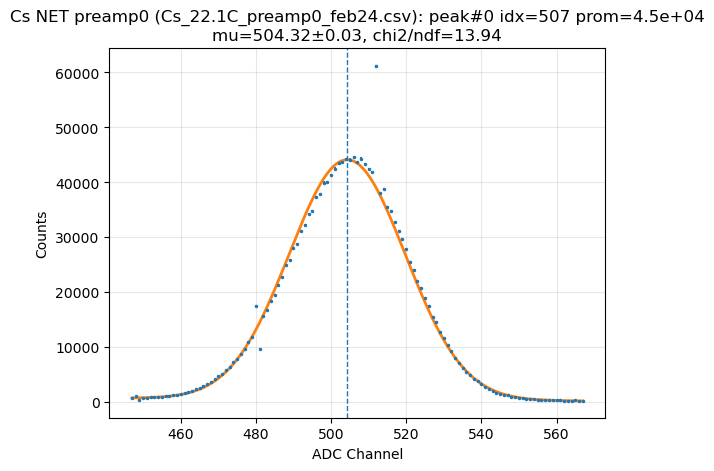

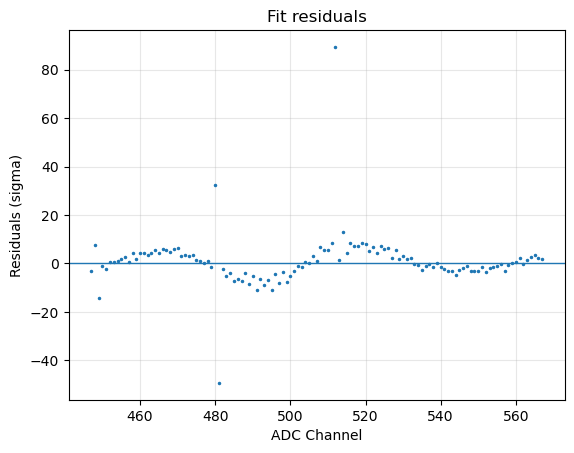

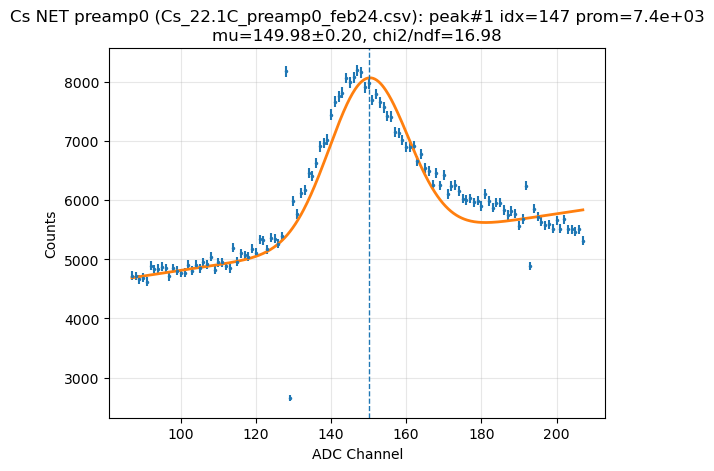

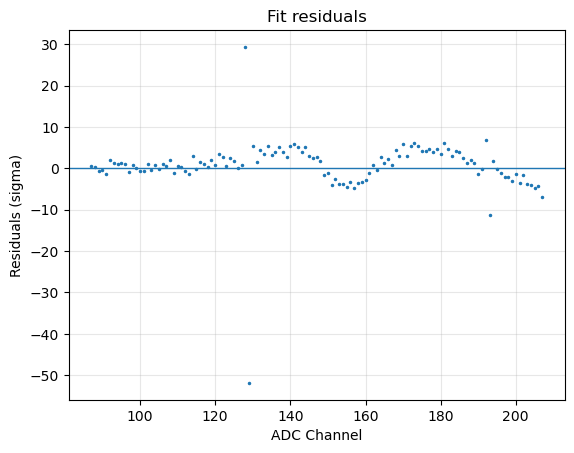

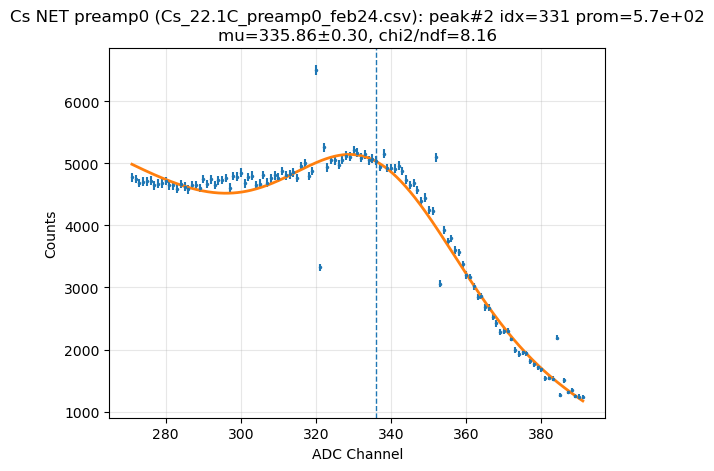

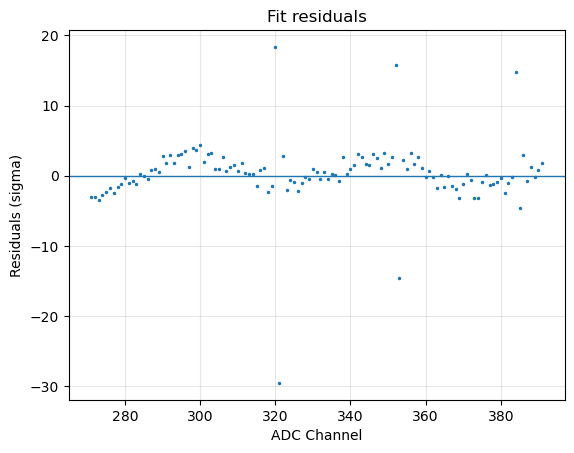

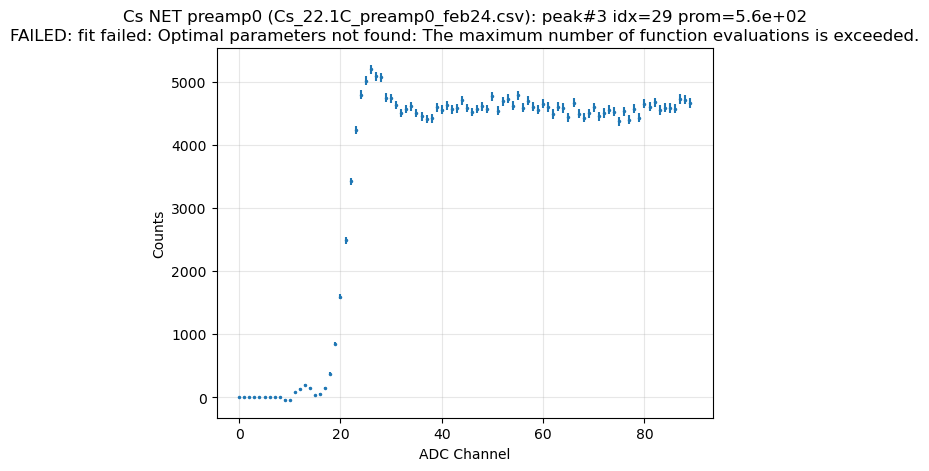

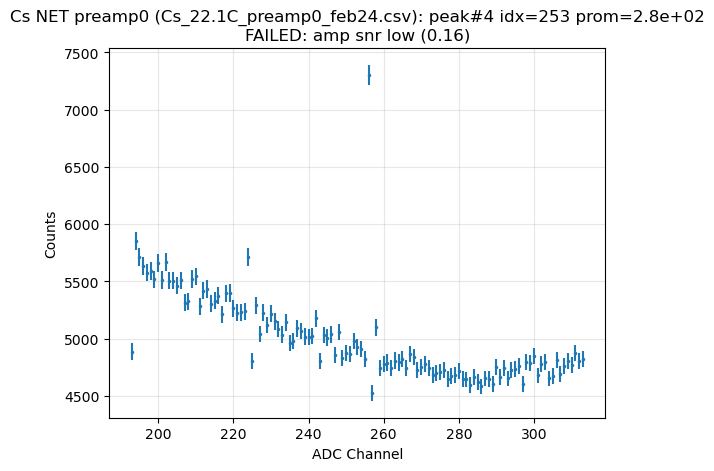

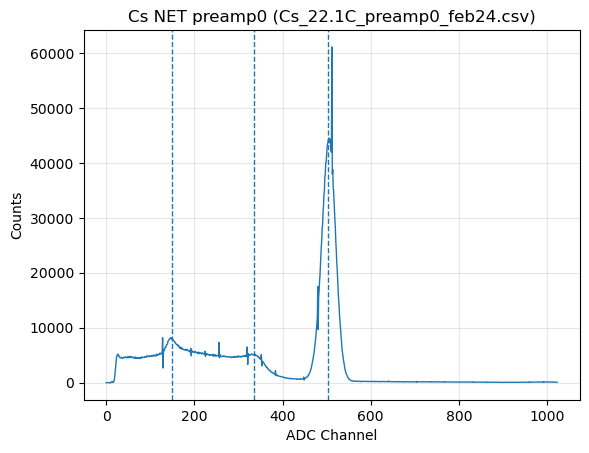

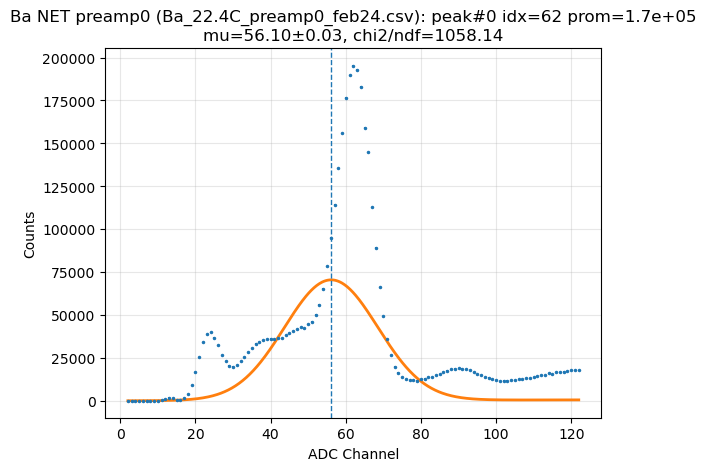

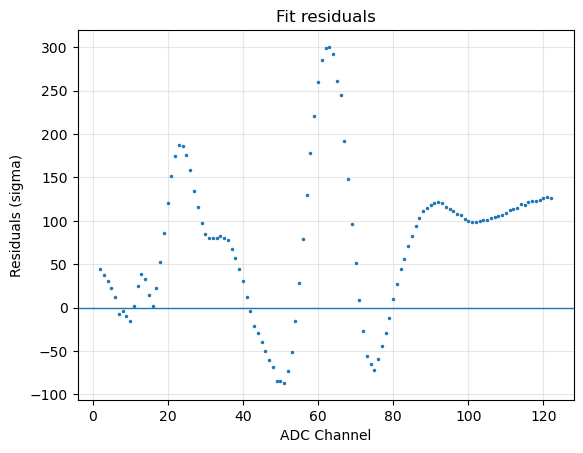

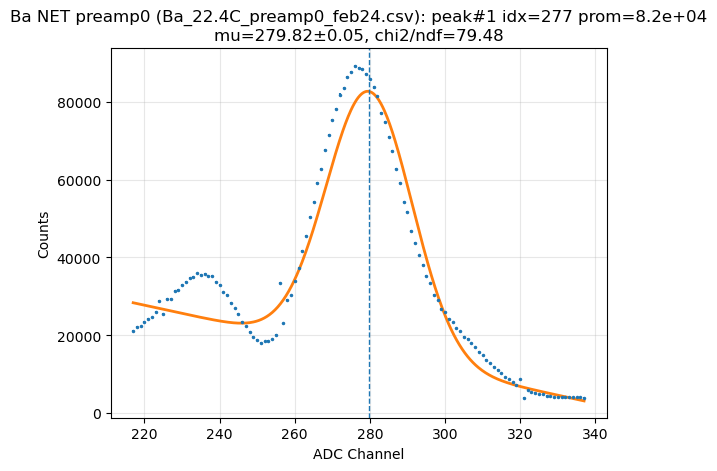

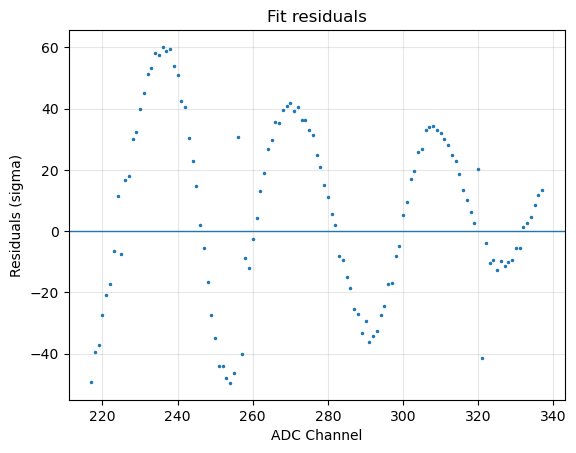

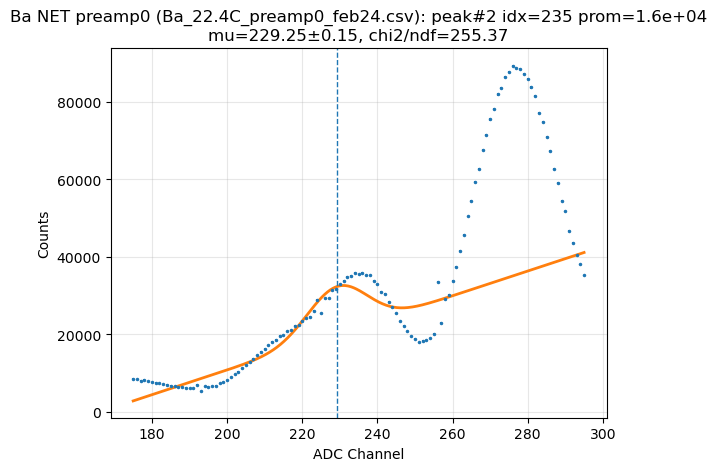

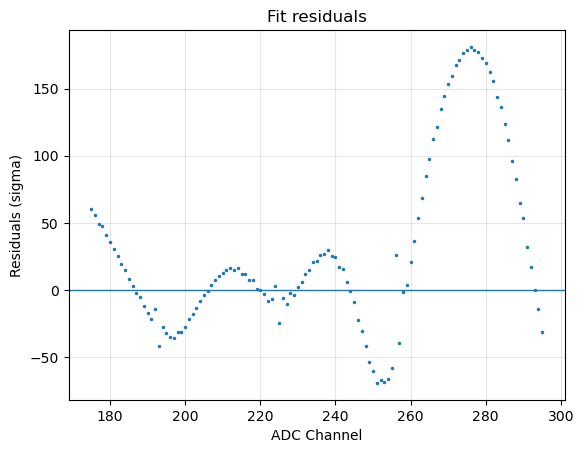

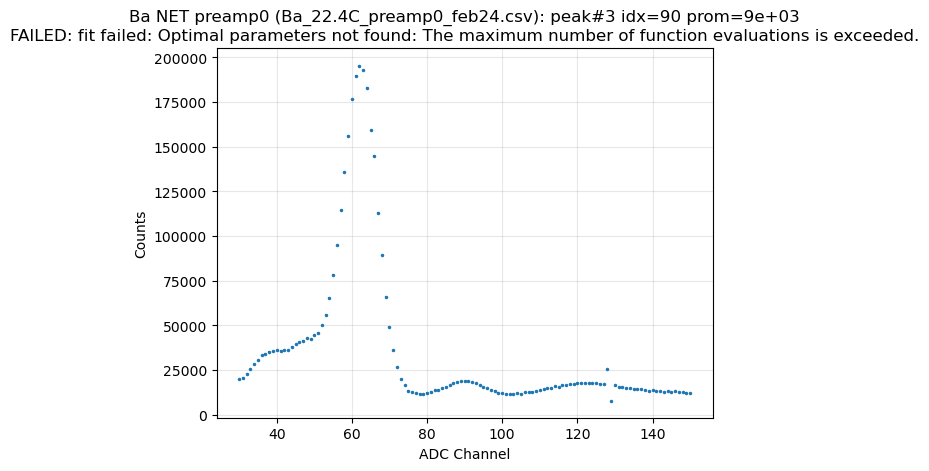

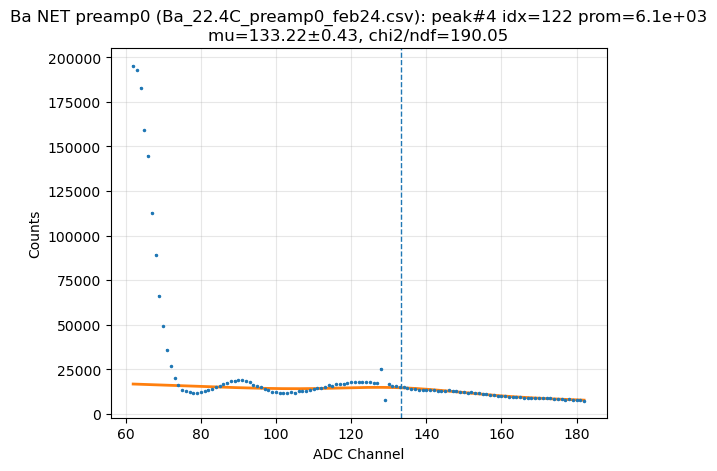

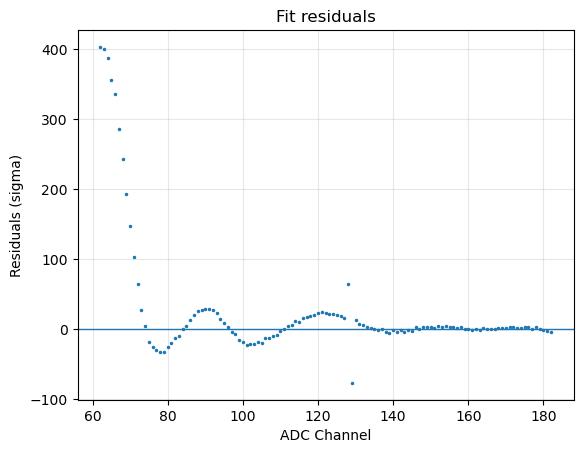

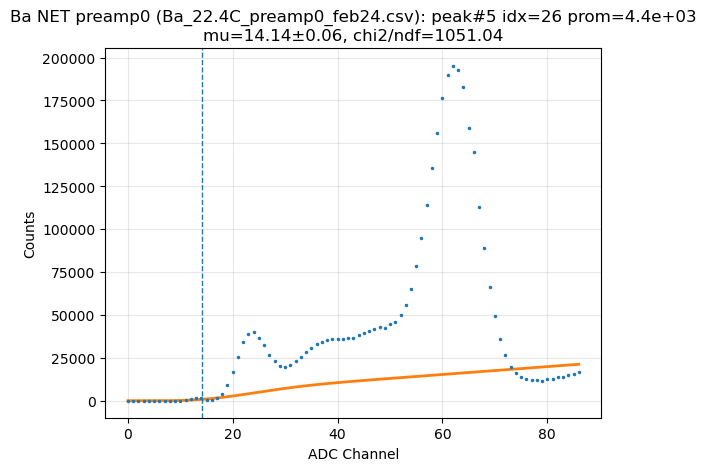

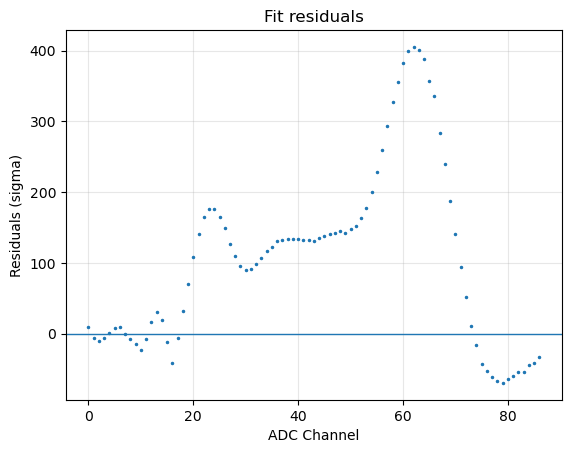

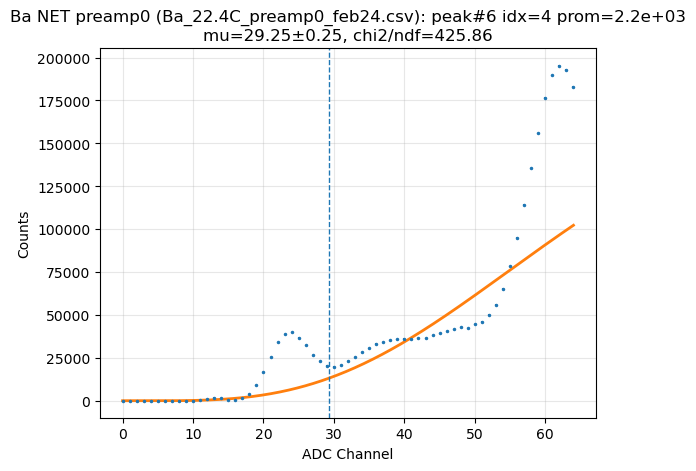

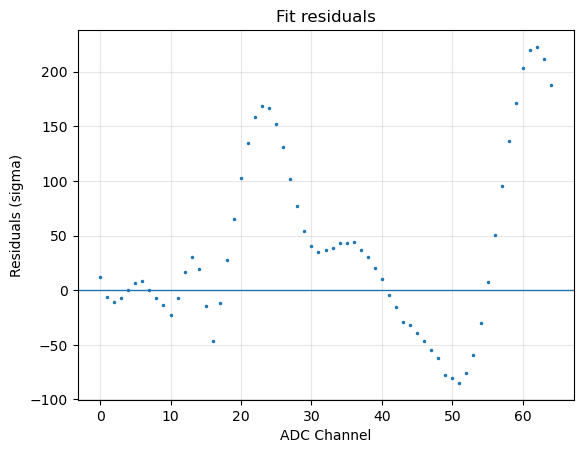

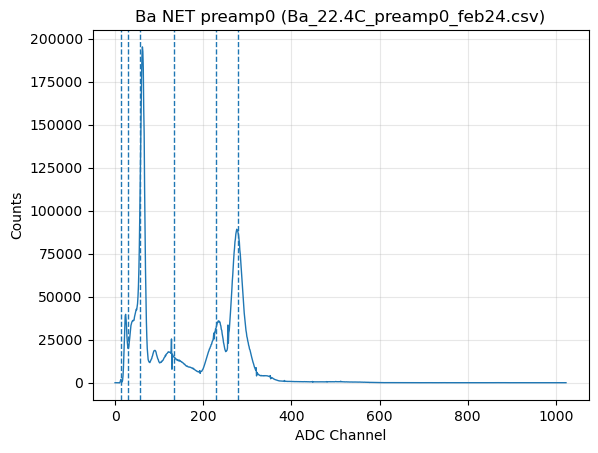

/tmp/ipykernel_4885/934636265.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt0, _ = curve_fit(cal_linear, ch, E)


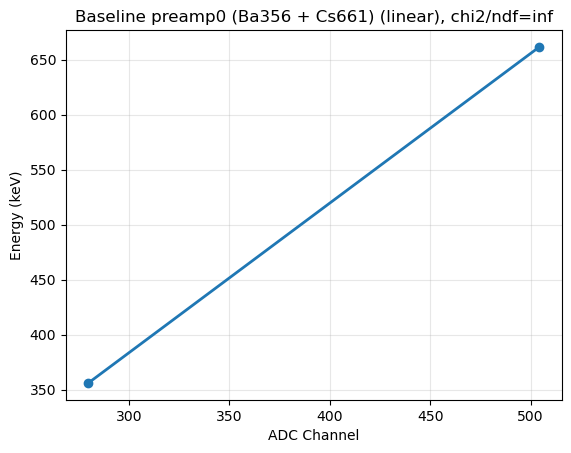

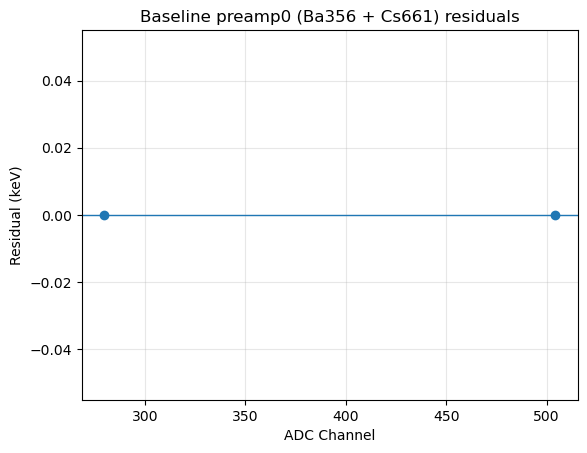

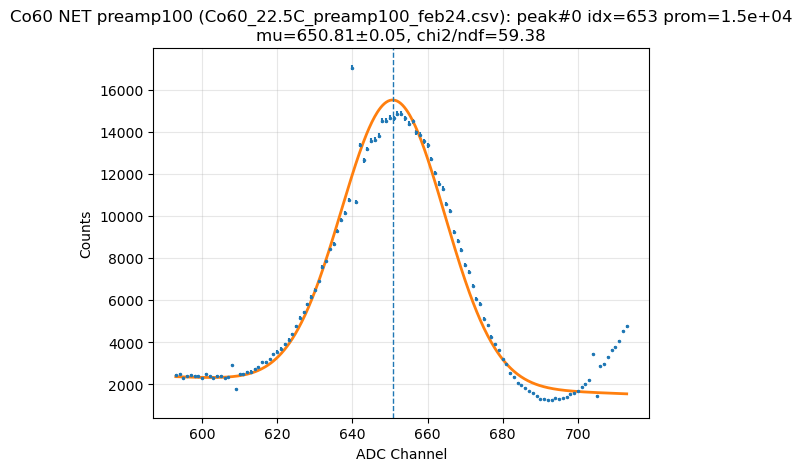

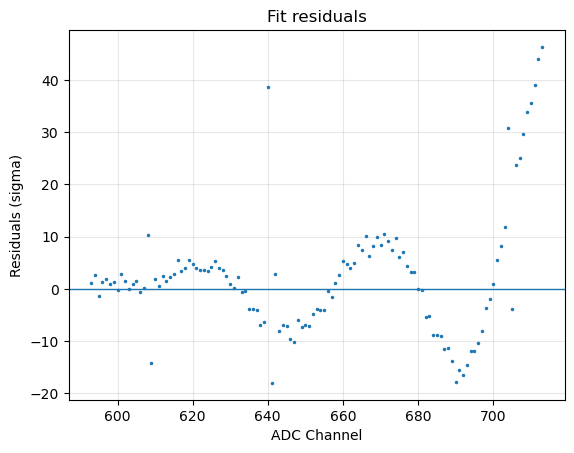

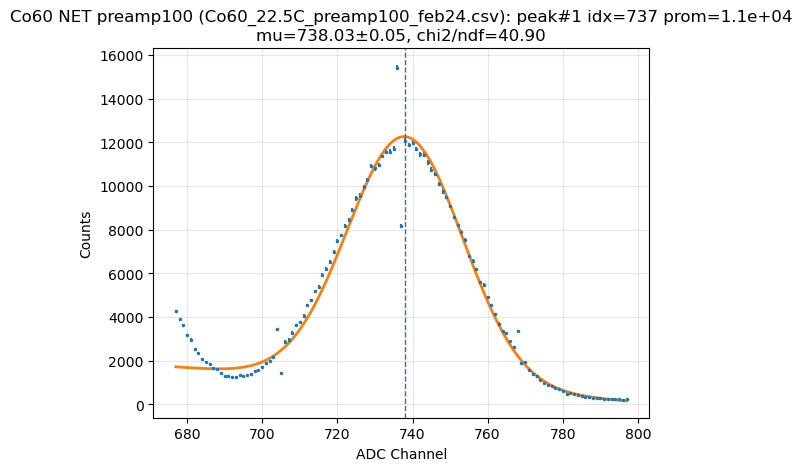

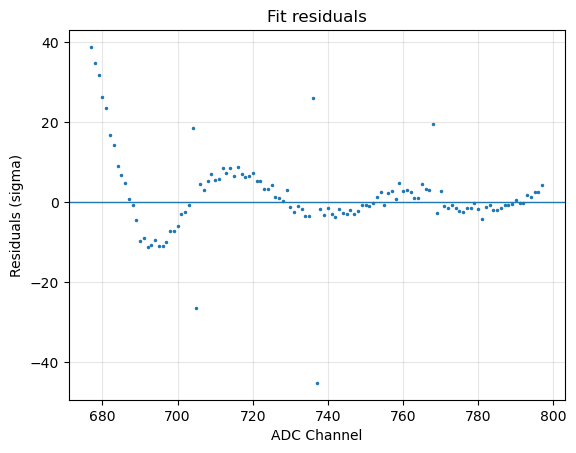

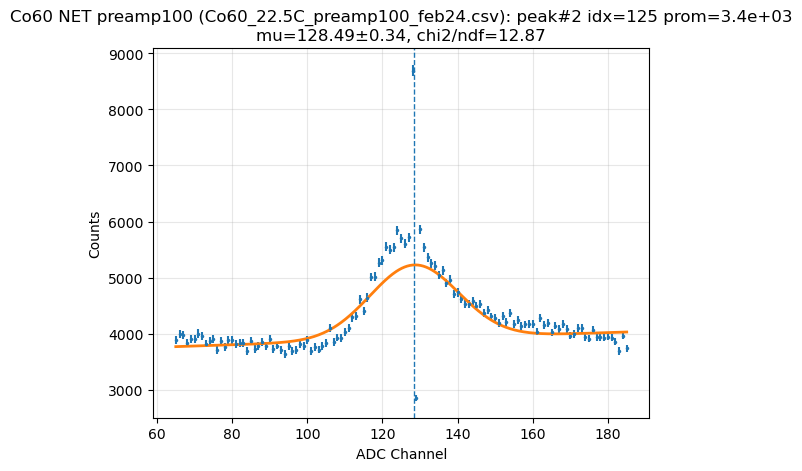

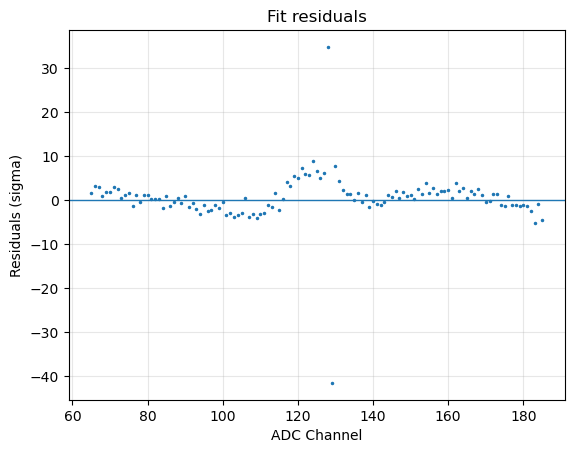

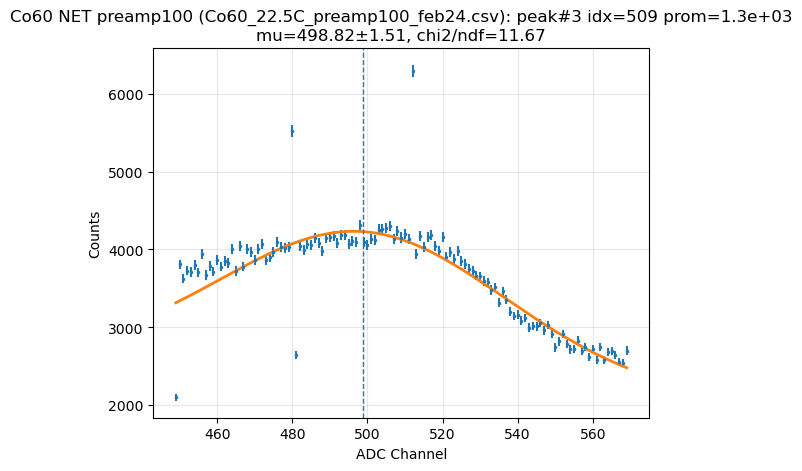

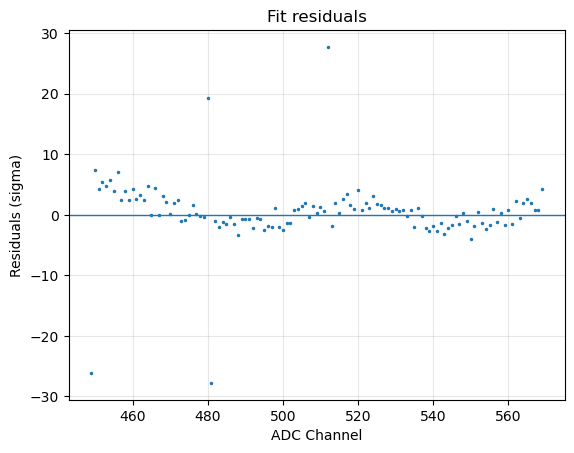

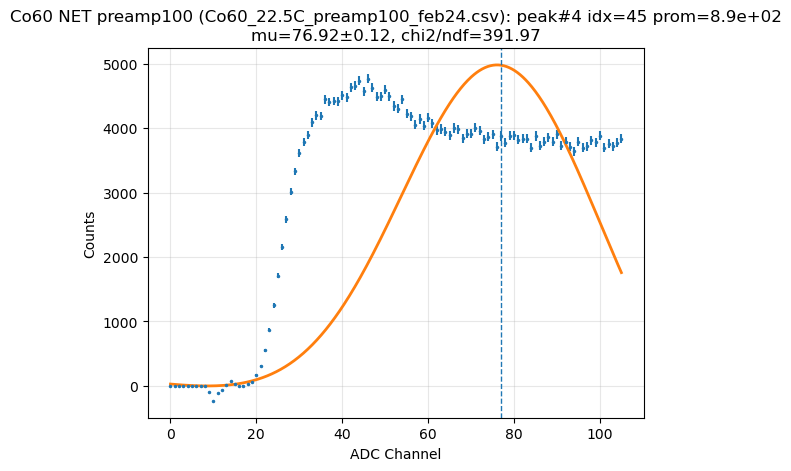

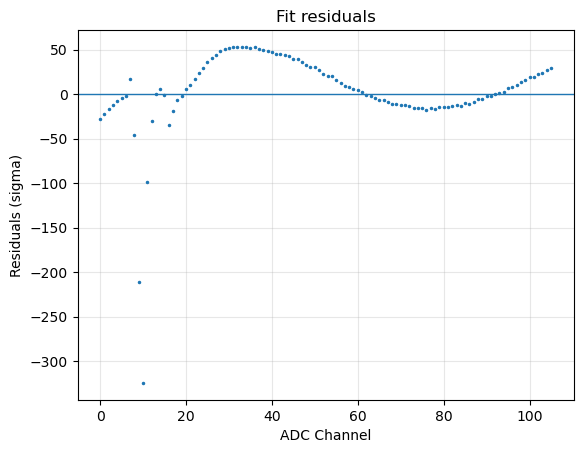

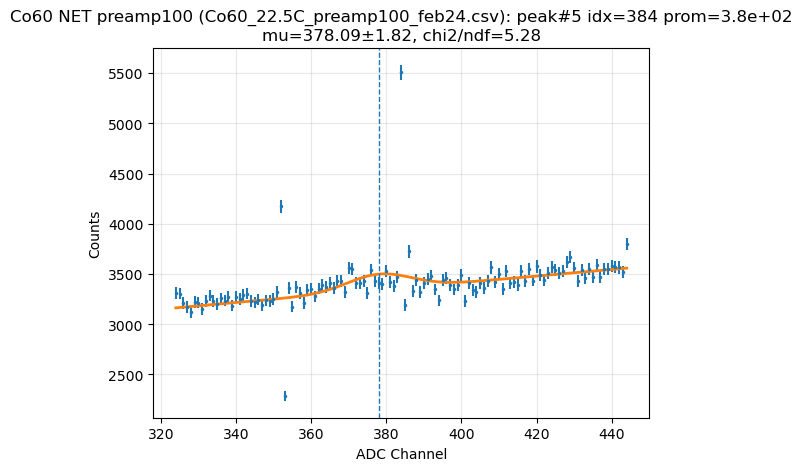

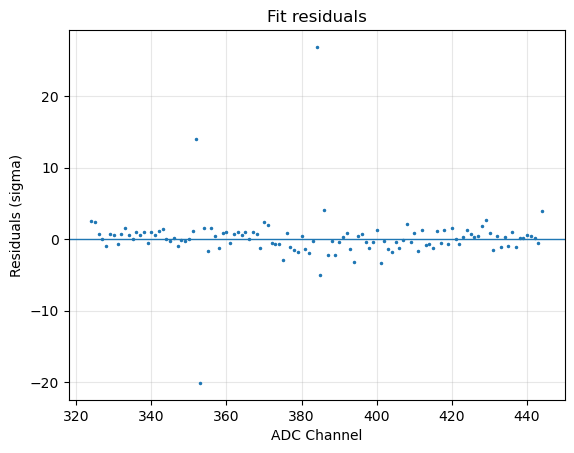

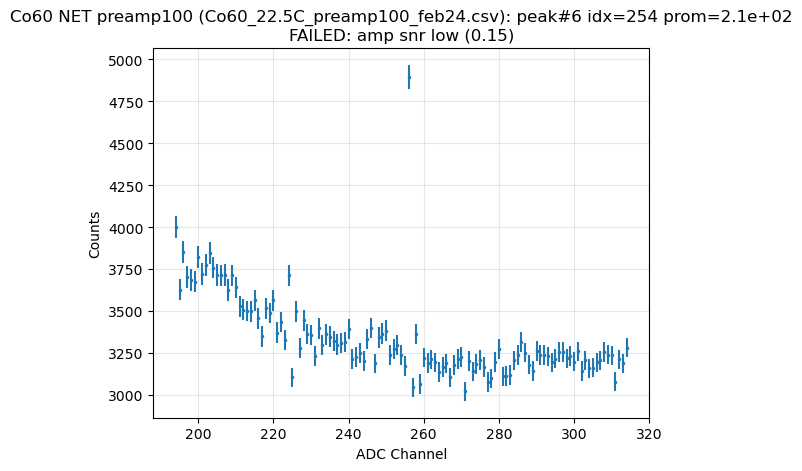

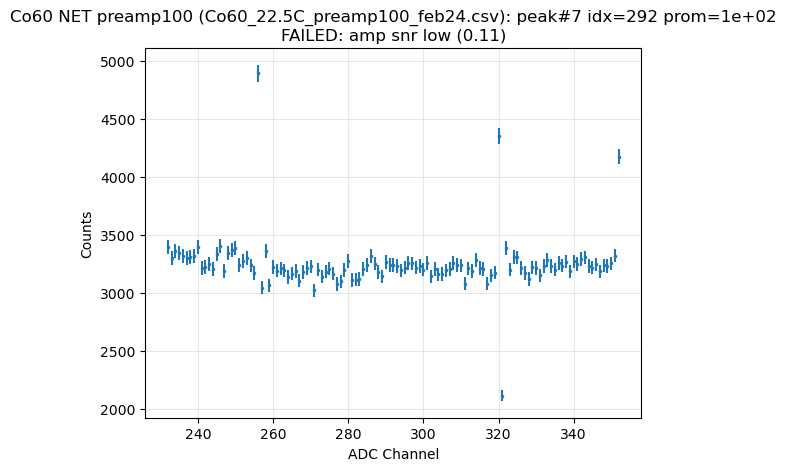

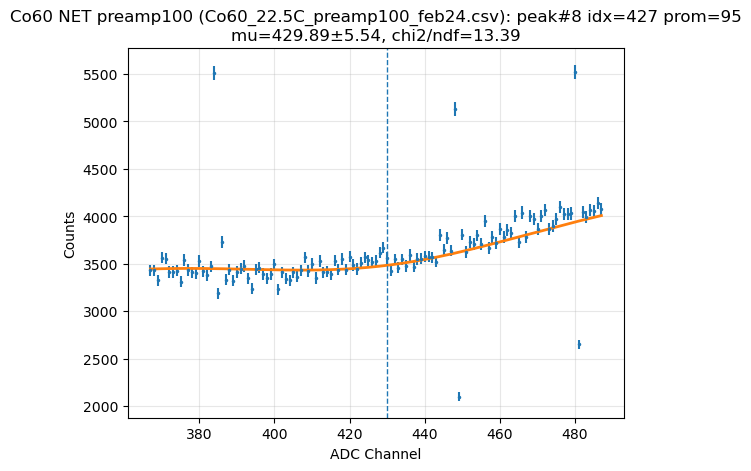

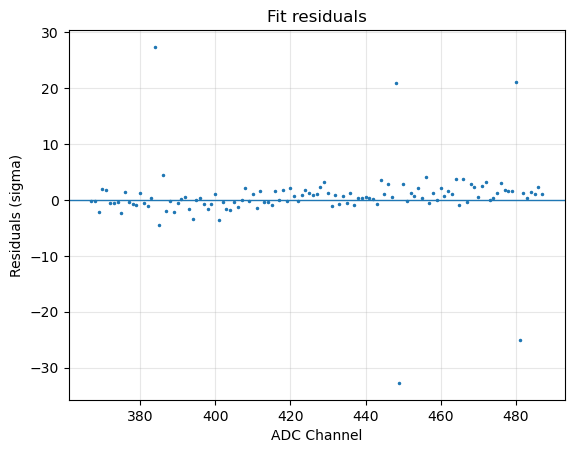

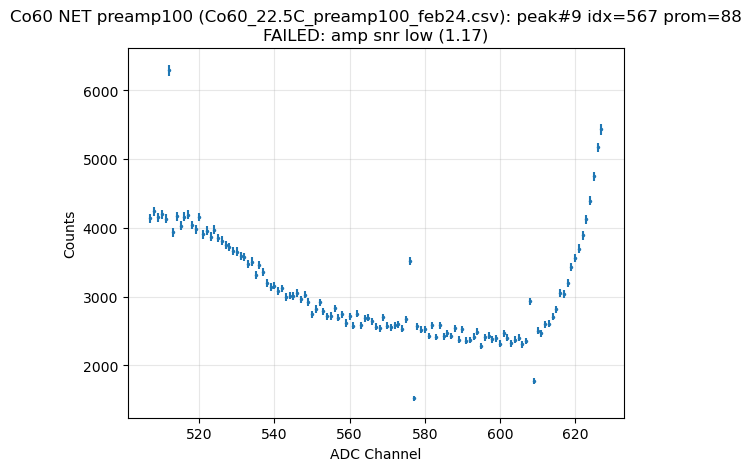

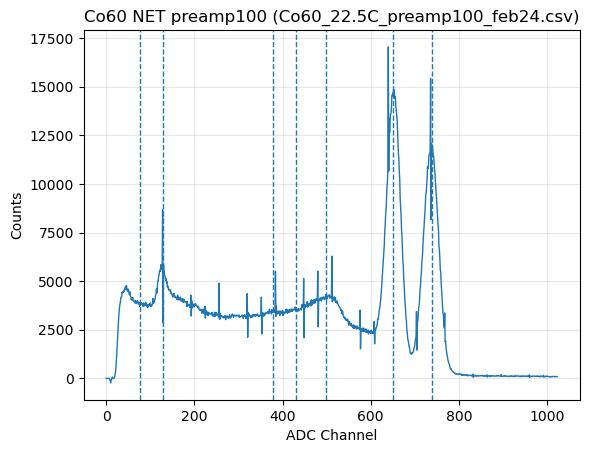

/tmp/ipykernel_4885/934636265.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt0, _ = curve_fit(cal_linear, ch, E)


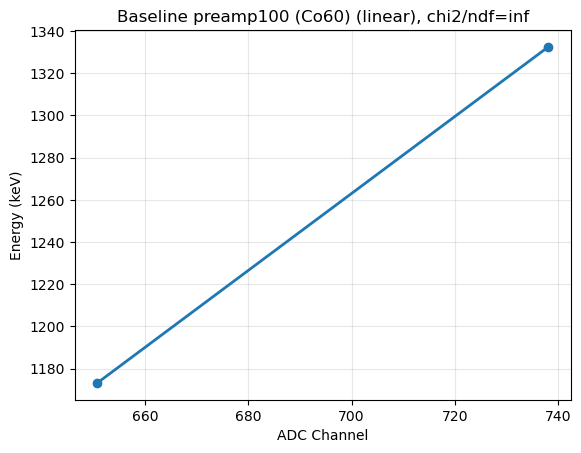

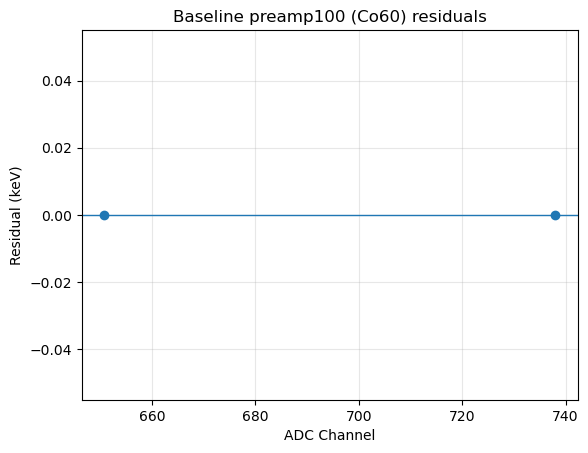


RESULTS
preamp0 calibration: [  1.36146476 -24.95402665]
preamp100 calibration: [  1.82596276 -15.12548728]


In [15]:
# -----------------------------
# RUN (Baseline discovery + debug plots)
# -----------------------------
all_csvs = list_csvs(ROOT_CAL)
print(f"Found {len(all_csvs)} CSVs under {ROOT_CAL}")

# Baseline Feb 24 files (FIXED selection)
baseline_cs   = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_0",   isotope="Cs")
baseline_ba   = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_0",   isotope="Ba")
baseline_co60 = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_100", isotope="Co60")
baseline_na   = select_isotope(all_csvs, date_folder="feb_24", preamp_folder="preamp_100", isotope="Na")

print("baseline_cs:", baseline_cs)
print("baseline_ba:", baseline_ba)
print("baseline_co60:", baseline_co60)
print("baseline_na:", baseline_na)

bg_path = BG_DEFAULT if (BG_DEFAULT is not None and BG_DEFAULT.exists()) else None
print("bg_path:", bg_path)

# sanity: print dt
if bg_path is not None:
    bg = read_spectrum_csv(bg_path)
    print("BG dt_seconds:", bg.dt_seconds, {k: bg.meta.get(k) for k in ["elapsed_real_time_s","dt_seconds","start_time","end_time"]})

if baseline_cs is None:
    raise RuntimeError("Could not find baseline Cs file. Check your folder names or isotope prefixes in filenames.")
if baseline_co60 is None:
    raise RuntimeError("Could not find baseline Co60 file. Check your folder names or isotope prefixes in filenames.")

cal0, info0 = build_baseline_preamp0(baseline_cs, baseline_ba, bg_path=bg_path)
cal100, info100 = build_baseline_preamp100(baseline_co60, baseline_na, bg_path=bg_path)

print("\nRESULTS")
print("preamp0 calibration:", cal0.params if cal0 else None)
print("preamp100 calibration:", cal100.params if cal100 else None)
